In [13]:

from pylibCZIrw import czi as pyczi
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from skimage.morphology import skeletonize, white_tophat, disk
from skimage.morphology import closing as morpho_closing
from skimage.filters import frangi, gaussian, threshold_otsu
from scipy import ndimage
from scipy.spatial import cKDTree
from skimage.measure import label
from scipy.stats import kruskal
from itertools import combinations
import numpy as np
from spotiflow.model import Spotiflow



directory_1 = "/Users/ctuna/Desktop/axon_codes/data/x63 bmi tubulin iii_data/"
directory_2 = "/Users/ctuna/Desktop/axon_codes/data/x63 Ni tubulin_data/"
directory_3 = "/Users/ctuna/Desktop/axon_codes/data/x63 scr tubIII ID8221225_data/" 

In [14]:
model = Spotiflow.from_pretrained("general")

INFO:spotiflow.model.spotiflow:Loading pretrained model: general


In [19]:
def get_label(directory):
    basename = os.path.basename(os.path.normpath(directory))
    parts = basename.split()
    return parts[1] if len(parts) > 1 else basename


def process_directory(directory):
    """Run spot detection on all .czi files; returns list of (filename, img_2d, points)."""
    results = []
    for filename in sorted(os.listdir(directory)):
        if not filename.endswith(".czi"):
            continue
        file_path = os.path.join(directory, filename)
        with pyczi.open_czi(file_path) as czidoc:
            bbox = czidoc.total_bounding_box
            z_start, z_size = bbox.get('Z', (0, 1))
            t_start = bbox.get('T', (0, 1))[0]
            # Max-project over Z for channel 0 at the first timepoint
            slices = []
            for z in range(z_start, z_start + z_size):
                plane = czidoc.read(plane={'C': 0, 'Z': z, 'T': t_start})
                slices.append(plane[..., 0].astype(np.float32))
        img_2d = np.max(slices, axis=0) if len(slices) > 1 else slices[0]
        points, details = model.predict(img_2d, verbose=False)
        results.append((filename, img_2d, points))
    return results


def plot_comparison(directory_1, directory_2, directory_3):
    all_dirs = [directory_1, directory_2, directory_3]
    all_results = [process_directory(d) for d in all_dirs]
    data   = [[len(r[2]) for r in res]                        for res in all_results]
    fnames = [[os.path.splitext(r[0])[0] for r in res]        for res in all_results]
    labels = [get_label(d) for d in all_dirs]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(data, labels=labels, widths=0.4)

    colors = ['steelblue', 'tomato', 'seagreen']
    rng = np.random.default_rng(0)

    for i, (counts, fnames_group, color) in enumerate(zip(data, fnames, colors), start=1):
        xs = rng.normal(i, 0.05, size=len(counts))
        ax.scatter(xs, counts, s=50, color=color, zorder=3, alpha=0.9)
        for x, y, fname in zip(xs, counts, fnames_group):
            ax.annotate(fname, xy=(x, y), xytext=(6, 0),
                        textcoords='offset points',
                        fontsize=8, va='center', color=color)

    ax.set_ylabel('Number of Spots')
    ax.set_title('Comparison of Spot Counts Across Datasets')
    plt.tight_layout()
    plt.show()


def show_spots(directory, max_images=3):
    results = process_directory(directory)[:max_images]
    label = get_label(directory)
    n = len(results)
    if n == 0:
        print(f"No .czi files found in {directory}")
        return
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]
    for ax, (filename, img_2d, points) in zip(axes, results):
        vmin, vmax = np.percentile(img_2d, [1, 99])
        ax.imshow(img_2d, cmap='gray', vmin=vmin, vmax=vmax)
        if len(points) > 0:
            ax.scatter(points[:, 1], points[:, 0], s=12, c='red',
                       marker='o', linewidths=0, alpha=0.8)
        ax.set_title(f"{filename}\n{len(points)} spots", fontsize=9)
        ax.axis('off')
    plt.suptitle(label, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


/var/folders/wn/2ktvmvf11gg5_vwy7_v2ys6m0000gp/T/ipykernel_92261/3881630994.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, widths=0.4)


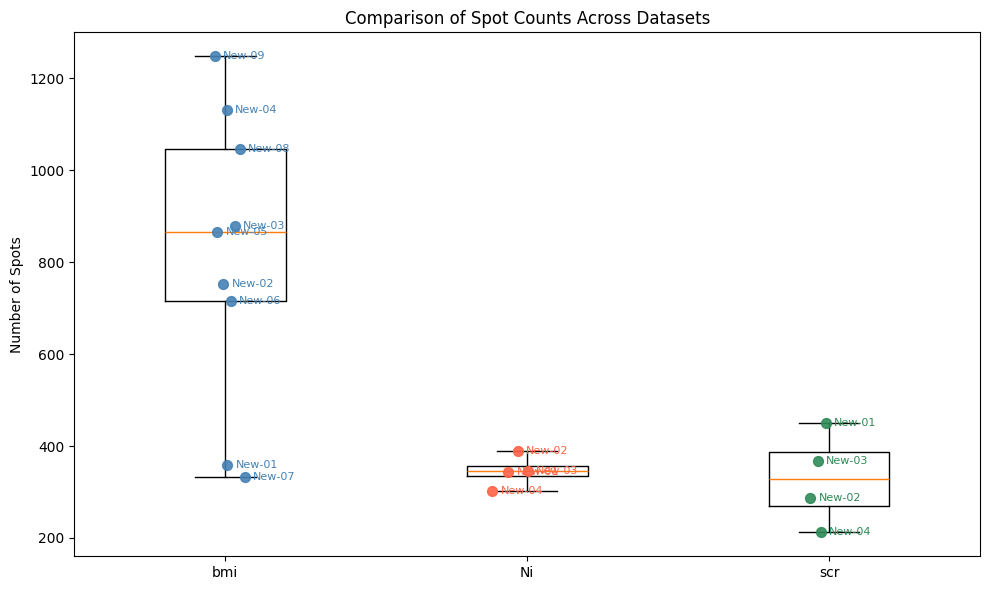

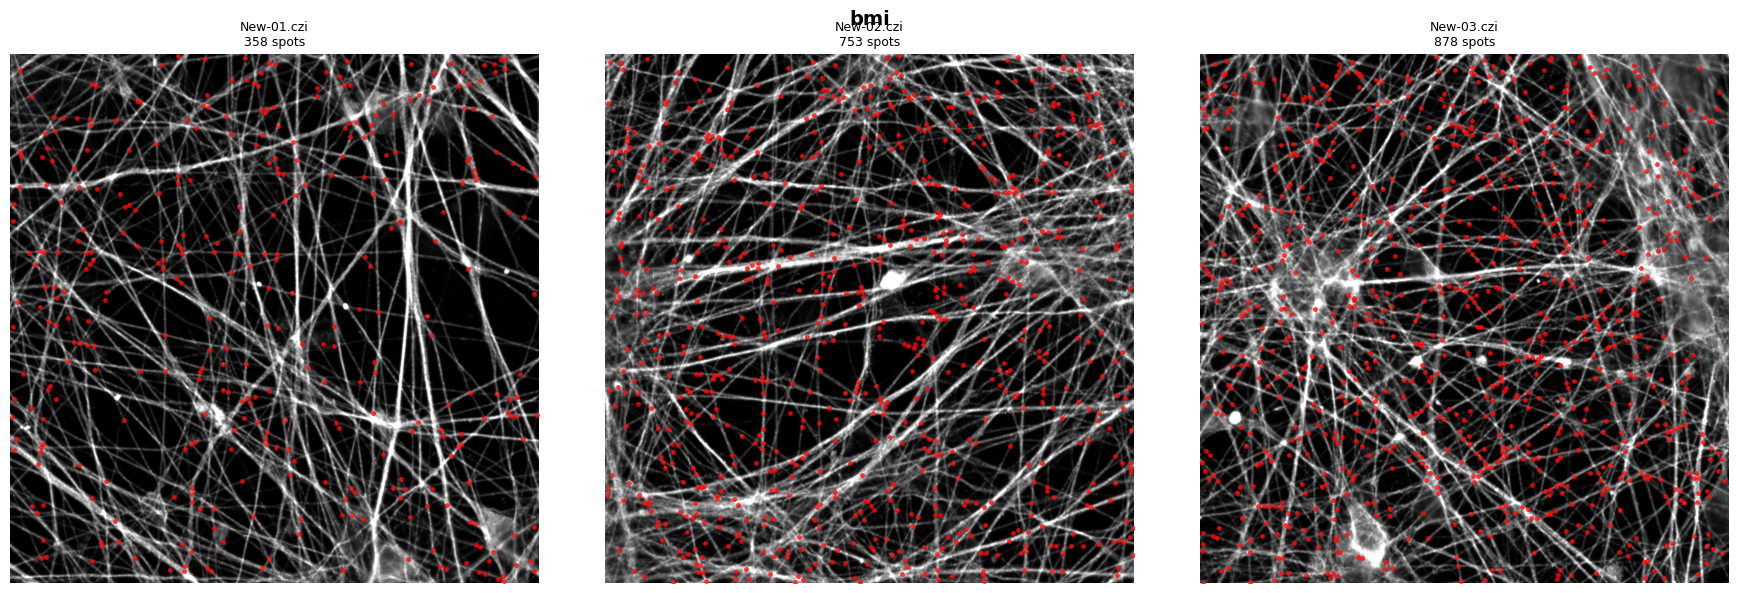

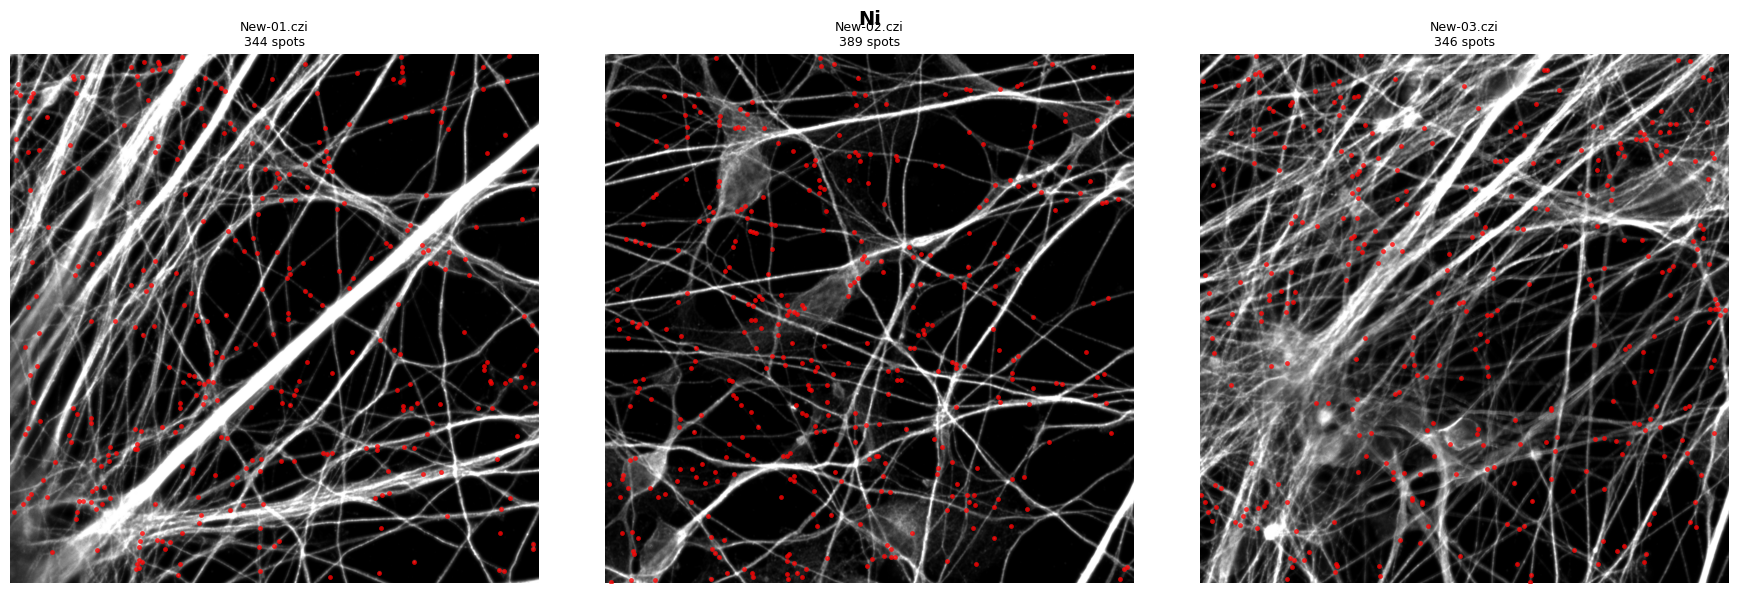

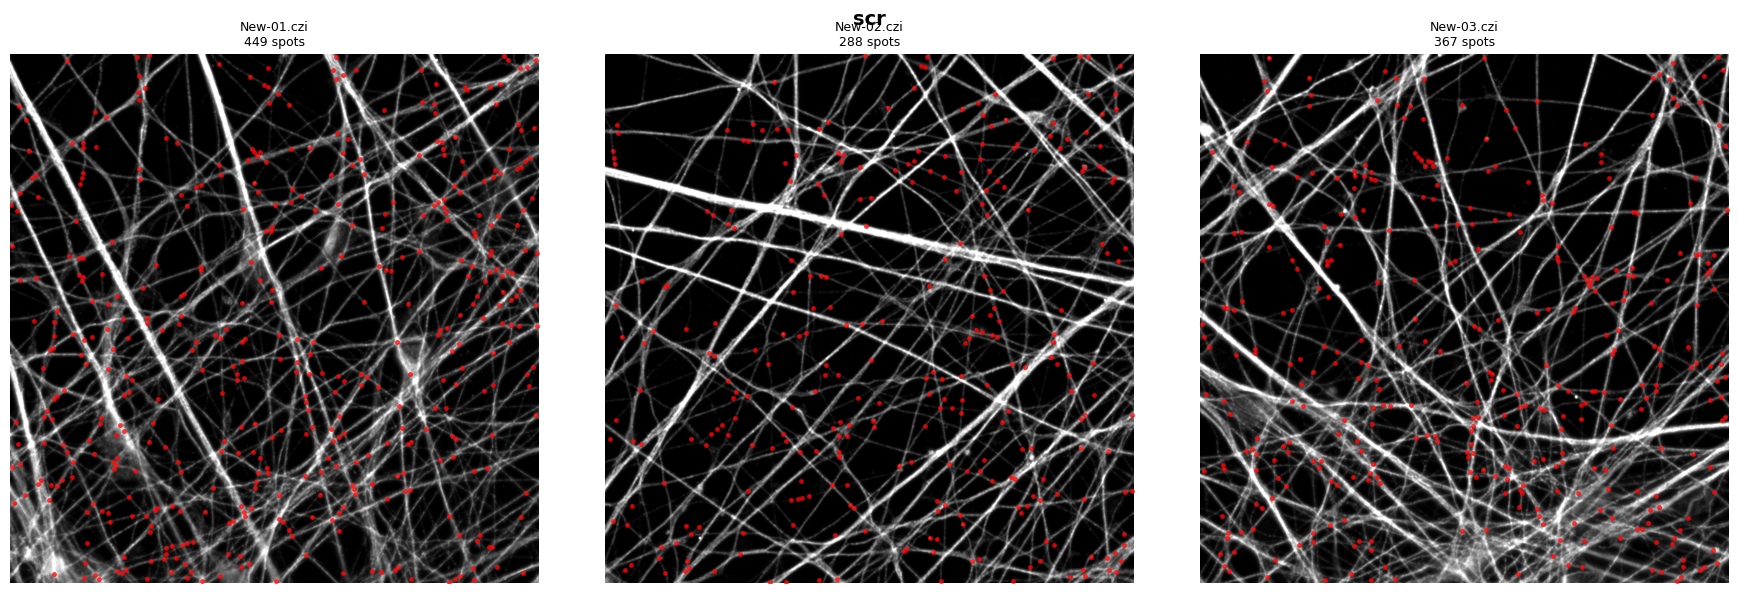

In [20]:
plot_comparison(directory_1, directory_2, directory_3)

for d in [directory_1, directory_2, directory_3]:
    show_spots(d)
